In [62]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

Reading the file:

In [6]:
filepath = os.path.join(os.getcwd(), 'species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Mapping the taxon ids to taxon latin names: 

In [7]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

Create pandas Dataframe from the data: 

In [8]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data['train_ids']
})
df['taxon_name'] = [species_ids_names[id] for id in data['train_ids'].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


In [9]:
df.shape

(272037, 4)

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [10]:
df = df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
df.shape

(272037, 4)

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [11]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)

In [12]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded'])
df.shape

(237977, 6)

<small>4. Validate species IDs: </small>

In [13]:
df['taxon_id'].isna().sum()

np.int64(0)

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [16]:
taxa = pd.read_csv('taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

35102

In [17]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape

(151391, 6)

<small>6. Convert to categorical labels:</small>

In [18]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['taxon_id'])
df.head()

,latitude,longitude,taxon_id,taxon_name,lat_rounded,lon_rounded,label
53,21.086105,-86.852867,3117,Patagioenas flavirostris,21.086100,-86.852867,20
54,19.186003,-96.199600,3117,Patagioenas flavirostris,19.186001,-96.199600,20
55,17.538877,-89.113724,3117,Patagioenas flavirostris,17.538879,-89.113724,20
56,20.648556,-105.220955,3117,Patagioenas flavirostris,20.648560,-105.220947,20
57,18.409698,-95.096657,3117,Patagioenas flavirostris,18.409700,-95.096657,20


<small>7. Append the climate data</small>

In [20]:
df = pd.read_csv('bird_species_with_climate.csv')

<small>8. Clean the climate data</small>

In [21]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (151391, 10)
Shape without nan data: (150194, 10)


In [22]:
(df['Tmax_avg'] < df['Tmin_avg']).sum()

np.int64(0)

<small>9. Split the data to x and y and normalize the climate features</small>

In [23]:
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.fit_transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,150194.000000,150194.000000,1.501940e+05,1.501940e+05,1.501940e+05
mean,15.544443,-9.343506,-1.937749e-16,-1.271648e-16,1.831779e-16
std,32.019650,95.974393,1.000003e+00,1.000003e+00,1.000003e+00
min,-75.284950,-178.060320,-6.684864e+00,-6.659755e+00,-1.640339e+00
25%,-19.905400,-96.408343,-6.481463e-01,-7.715034e-01,-6.507734e-01
50%,27.829345,-47.548143,1.810142e-02,1.161172e-01,-1.759906e-01
75%,41.539592,73.949602,6.747353e-01,7.379541e-01,3.944445e-01
max,72.515430,178.827590,2.290127e+00,2.249082e+00,1.336141e+01


<small>9. Split to train and validation sets</small>

In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

Exploratory Data Analysis:

In [25]:
df.head()

,latitude,longitude,taxon_id,taxon_name,lat_rounded,lon_rounded,label,Tmin_avg,Tmax_avg,Prec_avg
0,21.086105,-86.852870,3117,Patagioenas flavirostris,21.08610,-86.85287,20,20.967000,31.436000,103.416667
1,19.186003,-96.199600,3117,Patagioenas flavirostris,19.18600,-96.19960,20,19.327333,31.831333,117.833333
2,17.538877,-89.113720,3117,Patagioenas flavirostris,17.53888,-89.11372,20,19.496333,30.576333,125.583333
3,20.648556,-105.220955,3117,Patagioenas flavirostris,20.64856,-105.22095,20,19.674123,31.835527,87.750000
4,18.409698,-95.096660,3117,Patagioenas flavirostris,18.40970,-95.09666,20,20.515000,29.086000,156.750000


In [28]:
#possible biases in the dataset(skewness):

In [33]:
print("Latitude skewness:", df['latitude'].skew())
print("Longitude skewness:", df['longitude'].skew())

Latitude skewness: -0.5252804048562251
Longitude skewness: 0.47307048040097716


In [34]:
#Correlation analysis

<Axes: >

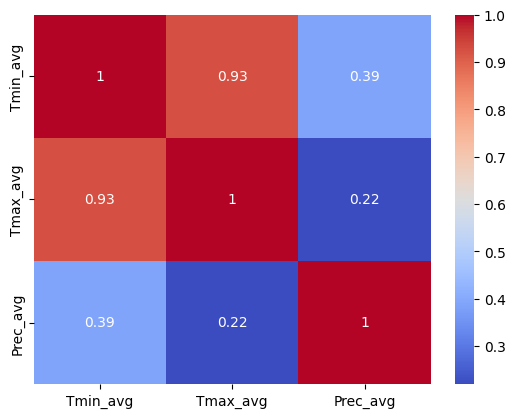

In [37]:
corr = df[['Tmin_avg', 'Tmax_avg', 'Prec_avg']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [63]:
# Encode species numerically if it's strings
X = df[['Tmin_avg', 'Tmax_avg', 'Prec_avg']]
y = df['taxon_id']

y_enc = LabelEncoder().fit_transform(y)

# ANOVA F-value
f_scores, p_values = f_classif(X, y_enc)
print("ANOVA F-scores:", f_scores)

ANOVA F-scores: [1202.2680644  1366.2089719   461.72254436]


In [38]:
# species and environment

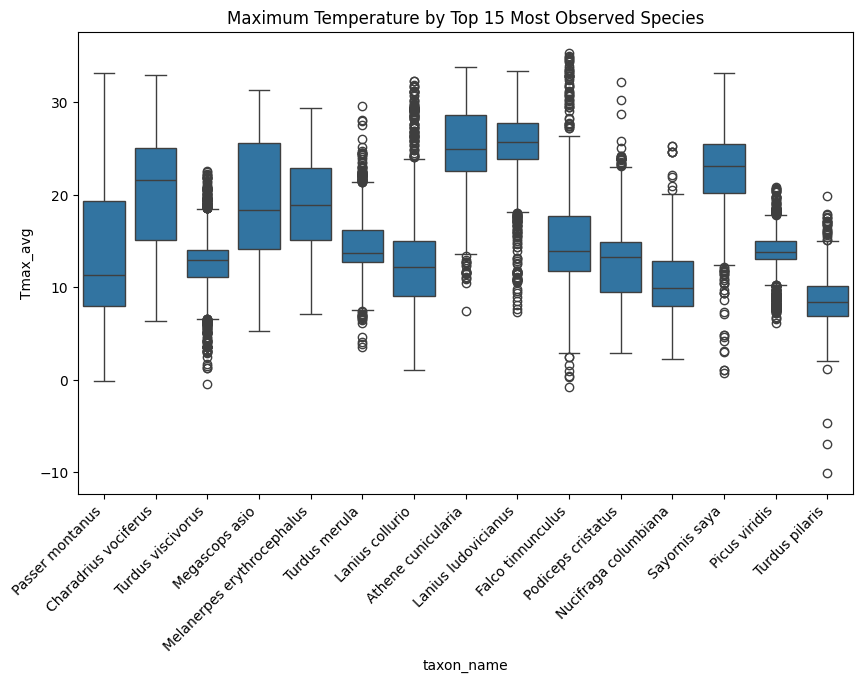

In [54]:
# choose the top 10 species to do the analysis 
top_species = df['taxon_name'].value_counts().head(15).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Tmax_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Maximum Temperature by Top 15 Most Observed Species')
plt.show()

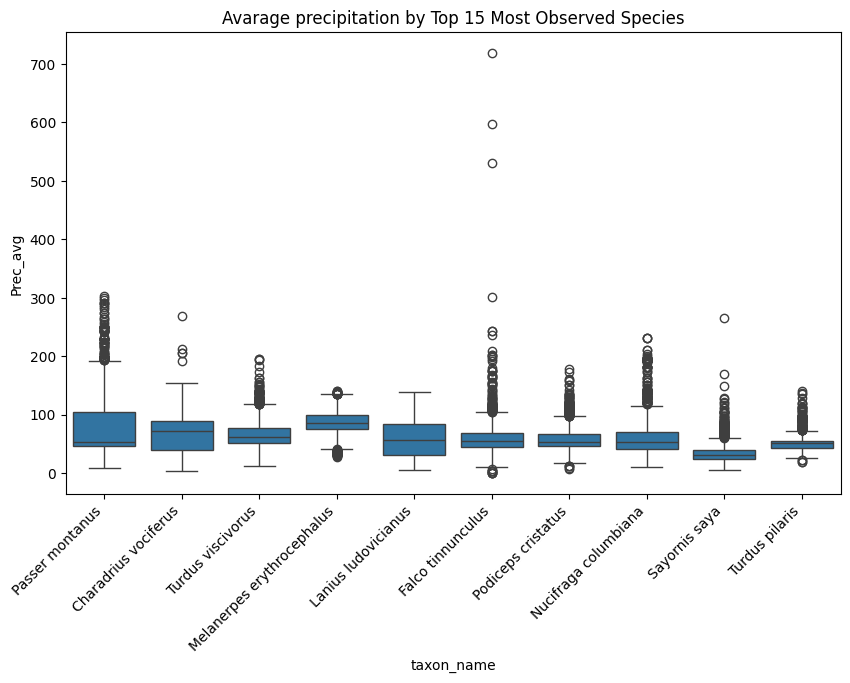

In [56]:
# choose the top 10 species to do the analysis 
top_species = df['taxon_name'].value_counts().head(10).index
df_top15 = df[df['taxon_name'].isin(top_species)]
plt.figure(figsize=(10,6))
sns.boxplot(x='taxon_name', y='Prec_avg', data=df_top15)
plt.xticks(rotation=45, ha='right')
plt.title('Avarage precipitation by Top 15 Most Observed Species')
plt.show()

Models:

In [20]:
# Model 1:

In [21]:
# Model 2:

In [22]:
# Model 3: